In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [43]:
df= pd.read_csv("student_dataset.csv")

In [44]:
df.sample(5)

,Study_Hours,Sleep_Hours,Practice_Tests,Score
73,0.681501,-0.039555,1.053153,32.085099
237,1.538037,0.361396,-0.645120,171.300684
282,0.035264,1.964725,-1.197878,163.810768
226,0.174578,1.886186,0.404051,170.863013
64,0.202923,0.632932,-0.552223,44.697033


In [45]:
X= df.iloc[:, 0:3]
y= df.iloc[:, 3]

# Train Test Split

In [46]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

In [47]:
pipeline= Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SGDRegressor(max_iter= 5000, eta0= 0.01, random_state= 42))
])
pipeline.fit(X_train, y_train)
y_pred= pipeline.predict(X_test)
results= pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(results)

         Actual   Predicted
203  -14.750187  -38.175356
266   59.176997   42.841361
152   96.512942   89.143096
9     65.586530   56.606272
233   45.305244   61.474682
226  170.863013  175.185222
196   71.446420   49.490644
109  -12.249393   -2.257707
5    -84.738621  -81.441585
175 -244.708174 -293.363431
237  171.300684  146.855057
57  -218.944940 -187.905345
218  352.052787  370.276331
45    46.731030   19.247920
182   40.675436   22.962303
221  -83.872911  -87.346520
289  134.705285  124.924301
211   80.735311  121.539093
148  133.175816  130.690973
165  -51.748693  -40.453590
78   -92.423221  -67.372897
113 -207.150541 -181.191160
249 -115.300980  -83.384198
250   18.468896   10.347589
104   12.789152   55.645947
42  -145.400655 -159.867800
281  184.051494  185.374626
295   86.500210   90.291996
157 -102.046313 -132.416387
238   24.196057   -0.541908
17  -146.288912 -157.778880
164  -91.211489  -75.299058
33    46.901355   62.607266
24   -62.380874  -47.822331
215 -254.009207 -264

In [48]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9715044599676526


In [49]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print(np.mean(scores))

0.9574617637917859


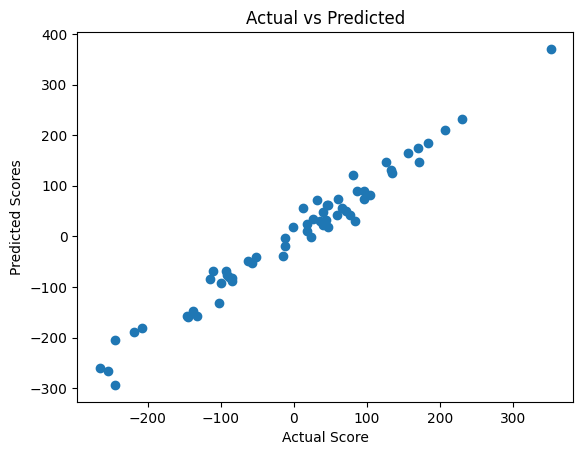

In [50]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

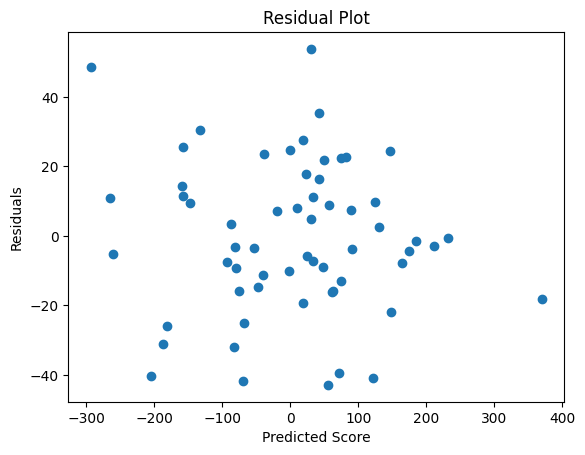

In [51]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

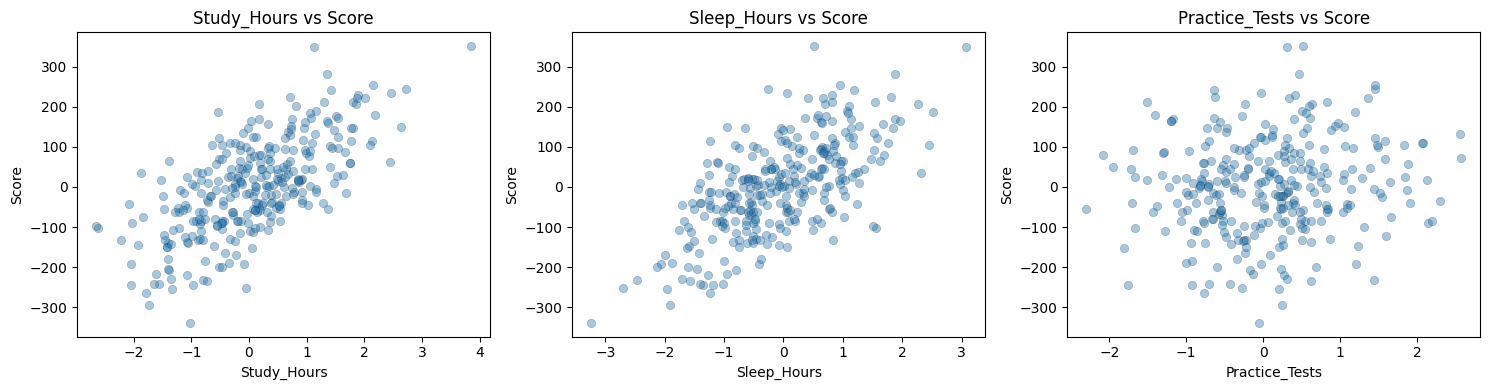

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, X.columns):
    ax.scatter(df[col], df['Score'], alpha=0.4, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel("Score")
    ax.set_title(f"{col} vs Score")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warning

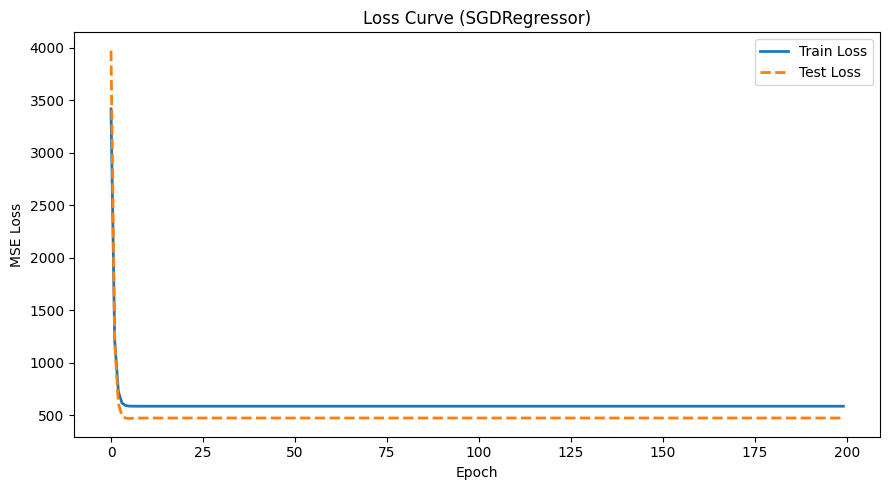

In [53]:
import numpy as np
import matplotlib.pyplot as plt

train_losses = []
test_losses = []

# Scale data for loss curve
scaler_lc = StandardScaler()
X_train_scaled = scaler_lc.fit_transform(X_train)
X_test_scaled = scaler_lc.transform(X_test)  # transform only, not fit!

model_lc = SGDRegressor(max_iter=1, warm_start=True, eta0=0.01, random_state=42)
# warm_start=True means:
# "Don't restart training from scratch — continue from where the model left off."

epochs = 200
# 1 epoch = model sees all 100 samples once
# 10 epochs = model sees all 100 samples 10 times

for epoch in range(epochs):
    model_lc.fit(X_train_scaled, y_train)
    
    train_pred = model_lc.predict(X_train_scaled)
    test_pred = model_lc.predict(X_test_scaled)
    
    train_loss = mean_squared_error(y_train, train_pred)
    test_loss = mean_squared_error(y_test, test_pred)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2, linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve (SGDRegressor)")
plt.legend()
plt.tight_layout()
plt.show()